# S&P 500 Clustering Pipeline
Single notebook with feature-case tuning, **k selection**, temporal stability evaluation (train → validation → test), and **mean + std aggregation** per stock.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 2. Load Data

In [4]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"
unseen_path = "data/sp500_unseen.csv"

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

# Split 5-year history into: first 4 years (notebook) + most recent year (unseen holdout)
data_start = df['Date'].min().normalize()
train_end = data_start + pd.DateOffset(years=3) - pd.Timedelta(days=1)
val_start = data_start + pd.DateOffset(years=3)
val_end = data_start + pd.DateOffset(years=4) - pd.Timedelta(days=1)
unseen_start = data_start + pd.DateOffset(years=4)
unseen_end = unseen_start + pd.DateOffset(years=1) - pd.Timedelta(days=1)

unseen_df = df[(df['Date'] >= unseen_start) & (df['Date'] <= unseen_end)].copy()
unseen_df.to_csv(unseen_path, index=False)

# Keep only first 4 years in the notebook workflow
notebook_df = df[(df['Date'] >= data_start) & (df['Date'] <= val_end)].copy()
df = notebook_df

print("Data start:", data_start.date())
print("Train + validation window:", data_start.date(), "to", val_end.date(), "(train+validation)")
print("Unseen window:", unseen_start.date(), "to", unseen_end.date())
print("Notebook rows:", len(df))
print("Unseen rows:", len(unseen_df))
print("Stocks in notebook window:", df['Symbol'].nunique())
print("Unseen CSV saved to:", unseen_path)
df.head(2)

Data start: 2021-03-22
Train + validation window: 2021-03-22 to 2025-03-21 (train+validation)
Unseen window: 2025-03-22 to 2026-03-21
Notebook rows: 500570
Unseen rows: 125599
Stocks in notebook window: 502
Unseen CSV saved to: data/sp500_unseen.csv


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005


## 3. Feature Engineering


In [12]:
import numpy as np
import pandas as pd

def create_features(df, include_today=True, use_log_volatility=False):
    """
    Create rolling-window features for clustering.

    Features:
      - log_return_1D
      - volume_change_1D
      - log_return_5D, log_return_21D       : rolling sum of daily log returns
      - volatility_5D, volatility_21D       : rolling std of daily log returns
      - volume_change_5D, volume_change_21D : rolling sum of daily log volume changes

    Options:
      include_today:
        True  -> feature windows end at t
        False -> feature windows are shifted back by 1 day to end at t-1

      use_log_volatility:
        False -> keep rolling std as volatility_* columns
        True  -> store log of rolling std as log_volatility_* columns
    """
    d = df.copy()
    d = d.sort_values(["Symbol", "Date"]).reset_index(drop=True)

    price_col = "Adj Close" if "Adj Close" in d.columns else "Close"

    # Base logged series
    d["log_price"] = np.log(d[price_col])
    d["log_volume"] = np.log(d["Volume"].clip(lower=1))

    g = d.groupby("Symbol", group_keys=False)

    # Daily base series
    d["log_return_1D"] = g["log_price"].diff(1)
    d["volume_change_1D"] = g["log_volume"].diff(1)

    windows = [5, 21]

    for w in windows:
        # Rolling cumulative return
        ret = (
            g["log_return_1D"]
            .rolling(w)
            .sum()
            .reset_index(level=0, drop=True)
        )

        # Rolling realized volatility
        vol = (
            g["log_return_1D"]
            .rolling(w)
            .std()
            .reset_index(level=0, drop=True)
        )

        # Rolling cumulative log-volume change
        vol_chg = (
            g["volume_change_1D"]
            .rolling(w)
            .sum()
            .reset_index(level=0, drop=True)
        )

        if not include_today:
            ret = ret.groupby(d["Symbol"]).shift(1)
            vol = vol.groupby(d["Symbol"]).shift(1)
            vol_chg = vol_chg.groupby(d["Symbol"]).shift(1)

        d[f"log_return_{w}D"] = ret
        d[f"volume_change_{w}D"] = vol_chg

        if use_log_volatility:
            eps = 1e-12
            d[f"log_volatility_{w}D"] = np.log(vol.clip(lower=eps))
        else:
            d[f"volatility_{w}D"] = vol

    return d

In [ ]:
feat = create_features(df)
feat.to_csv("feature_engineered_data.csv", index=False)

## 4. Time-based Split (3y / 1y / 1y)


In [ ]:
train = full_feat[(full_feat['Date'] >= data_start) & (full_feat['Date'] <= train_end)].copy()
val   = full_feat[(full_feat['Date'] >= val_start) & (full_feat['Date'] <= val_end)].copy()

print('Train window:', data_start.date(), 'to', train_end.date())
print('Validation window:', val_start.date(), 'to', val_end.date())
print('Train rows:', len(train))
print('Validation rows:', len(val))



## 5. Keep Only Stocks Available in All 3 Splits


In [ ]:
common_symbols = (
    set(train['Symbol'].unique())
    & set(val['Symbol'].unique())
)

train = train[train['Symbol'].isin(common_symbols)].copy()
val   = val[val['Symbol'].isin(common_symbols)].copy()

print('Common stocks:', len(common_symbols))
print('Train stocks:', train['Symbol'].nunique())
print('Validation stocks:', val['Symbol'].nunique())

train



## 6. Define Feature Cases

In [11]:
FEATURE_CASES = {
    "case_1": ['logret_1', 'logvol_1', 'vol_chg_1'],
    "case_2": ['logret_5', 'logvol_5', 'vol_chg_5'],
    "case_3": ['logret_21', 'logvol_21', 'vol_chg_21']
}

FEATURE_CASES


{'case_1': ['logret_1', 'logvol_1', 'vol_chg_1'],
 'case_2': ['logret_5', 'logvol_5', 'vol_chg_5'],
 'case_3': ['logret_21', 'logvol_21', 'vol_chg_21']}

## 7. Aggregate Daily Features to One Vector Per Stock
Each stock is represented by:
- the **mean** of every selected feature
- the **standard deviation** of time-varying features

All selected features contribute both mean and standard deviation to the stock-level summary.

In [12]:
def aggregate_features(df, feature_cols):
    # Mean of all selected features
    agg_mean = df.groupby('Symbol')[feature_cols].mean()
    # Standard deviation only for time-varying features
    cols_for_std = list(feature_cols)
    agg_std = df.groupby('Symbol')[cols_for_std].std()
    agg_std.columns = [f"{col}_std" for col in agg_std.columns]

    # Combine mean + std
    X = pd.concat([agg_mean, agg_std], axis=1)

    return X.dropna()

## 8. KMeans Helper Functions

In [13]:
def fit_kmeans(X, k):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    return model, scaler, labels, score, X_scaled

def apply_kmeans(X, model, scaler):
    X_scaled = scaler.transform(X)
    labels = model.predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    return labels, score, X_scaled

def evaluate_k_range(X, k_range=range(2, 9)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        inertia = model.inertia_

        rows.append({
            "k": k,
            "silhouette": sil,
            "inertia": inertia
        })

    return pd.DataFrame(rows), X_scaled

## 9. Compare Feature Cases on Training Set
For each feature case, search over candidate `k` values and keep the best silhouette score.

In [14]:
feature_case_results = []

for case_name, feature_cols in FEATURE_CASES.items():
    X_train_case = aggregate_features(train, feature_cols)
    k_results_case, _ = evaluate_k_range(X_train_case, k_range=range(2, 9))

    best_idx = k_results_case['silhouette'].idxmax()
    best_k_case = int(k_results_case.loc[best_idx, 'k'])
    best_sil_case = float(k_results_case.loc[best_idx, 'silhouette'])

    feature_case_results.append({
        "case": case_name,
        "features": ", ".join(feature_cols),
        "n_stocks": len(X_train_case),
        "aggregated_feature_count": X_train_case.shape[1],
        "best_k": best_k_case,
        "best_train_silhouette": best_sil_case
    })

feature_case_results_df = (
    pd.DataFrame(feature_case_results)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

feature_case_results_df

,case,features,n_stocks,aggregated_feature_count,best_k,best_train_silhouette
0,case_3,"logret_21, logvol_21, vol_chg_21",499,6,2,0.569157
1,case_2,"logret_5, logvol_5, vol_chg_5",499,6,2,0.556215
2,case_1,"logret_1, logvol_1, vol_chg_1",499,6,2,0.527696


## 10. Select Best Feature Case

In [15]:
best_case = feature_case_results_df.loc[0, 'case']
best_features = FEATURE_CASES[best_case]

print("Best feature case:", best_case)
print("Selected raw features:", best_features)

Best feature case: case_3
Selected raw features: ['logret_21', 'logvol_21', 'vol_chg_21']


## 11. Build Final Training Matrix

In [16]:
X_train = aggregate_features(train, best_features)

print("Training matrix shape:", X_train.shape)
print("Aggregated columns:")
print(list(X_train.columns))

X_train.head()

Training matrix shape: (499, 6)
Aggregated columns:
['logret_21', 'logvol_21', 'vol_chg_21', 'logret_21_std', 'logvol_21_std', 'vol_chg_21_std']


,logret_21,logvol_21,vol_chg_21,logret_21_std,logvol_21_std,vol_chg_21_std
Symbol,,,,,,
A,0.003473,0.017097,0.009891,0.078903,0.005214,0.499563
AAPL,0.009726,0.015948,-0.008466,0.074409,0.005772,0.366824
ABBV,0.018183,0.012049,-0.003392,0.062869,0.003770,0.464716
ABNB,-0.003440,0.029775,0.010216,0.130475,0.009681,0.677540
ABT,0.000751,0.013496,-0.000386,0.060589,0.004314,0.463441


## 12. Select the Number of Clusters (k)
Use **silhouette score** as the main criterion and **inertia** as supporting evidence.

In [17]:
k_results, _ = evaluate_k_range(X_train, k_range=range(2, 9))
k_results

,k,silhouette,inertia
0,2,0.569157,2190.544366
1,3,0.553032,1763.706271
2,4,0.326679,1433.046063
3,5,0.331376,1241.416586
4,6,0.326169,1066.573046
5,7,0.331625,915.733049
6,8,0.222712,827.978796


## 13. Plot Silhouette and Elbow Curves

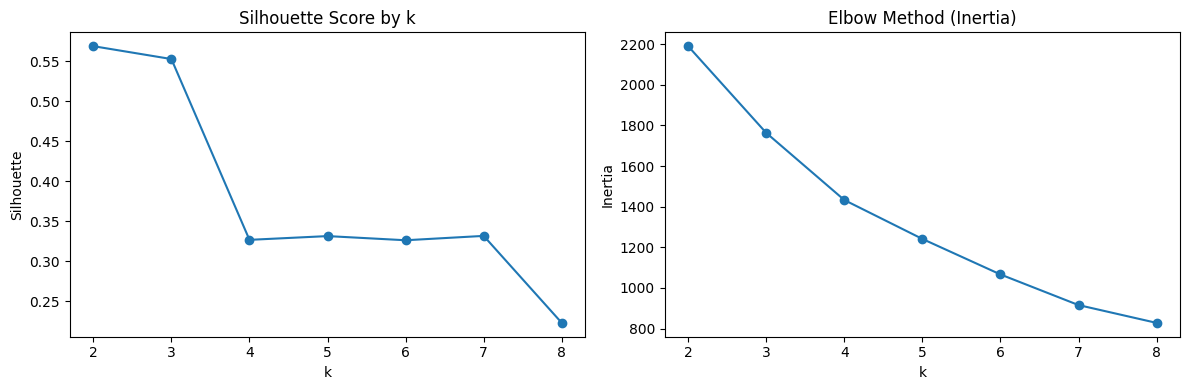

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_results['k'], k_results['silhouette'], marker='o')
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.subplot(1, 2, 2)
plt.plot(k_results['k'], k_results['inertia'], marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

## 14. Choose Best k

In [19]:
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print("Selected k:", best_k)

Selected k: 2


## 15. Fit Final Clustering on Train

In [20]:
model, scaler, train_labels, train_score, X_train_scaled = fit_kmeans(X_train, k=best_k)

train_clusters = pd.DataFrame({
    "Symbol": X_train.index,
    "Cluster_train": train_labels
})

print("Train silhouette:", round(train_score, 4))
train_clusters.head()

Train silhouette: 0.5692


,Symbol,Cluster_train
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,1
4,ABT,0


## 16. Evaluate Cluster Stability on Validation

In [21]:
X_val = aggregate_features(val, best_features)

common_train_val = X_train.index.intersection(X_val.index)
X_val = X_val.loc[common_train_val]

val_labels, val_score, X_val_scaled = apply_kmeans(X_val, model, scaler)

val_clusters = pd.DataFrame({
    "Symbol": X_val.index,
    "Cluster_val": val_labels
})

print("Validation silhouette:", round(val_score, 4))
val_clusters.head()

Validation silhouette: 0.5403


,Symbol,Cluster_val
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,0
4,ABT,0


## 17. Confirm Cluster Stability on Test

In [ ]:
print("Most recent year has been removed from notebook evaluation and exported to:")
print(unseen_path)
print("Unseen rows:", len(unseen_df))



## 18. Stability Summary

In [ ]:
stability_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "silhouette": [train_score, val_score]
})

stability_summary



## 19. Same-Stock Cluster Consistency

In [ ]:
train_val_compare = train_clusters.merge(val_clusters, on="Symbol", how="inner")

train_val_consistency = (train_val_compare["Cluster_train"] == train_val_compare["Cluster_val"]).mean()

print("Train vs Validation consistency:", round(train_val_consistency, 4))



## 20. Cluster Profiles on Training Set

In [25]:
train_profile = X_train.copy()
train_profile["Cluster"] = train_labels

cluster_profile = train_profile.groupby("Cluster").mean()
cluster_profile

,logret_21,logvol_21,vol_chg_21,logret_21_std,logvol_21_std,vol_chg_21_std
Cluster,,,,,,
0,0.006950,0.01694,0.003339,0.077722,0.005479,0.530765
1,-0.001103,0.03186,0.006831,0.153690,0.012880,0.683821


## 21. PCA Visualization of Training Clusters

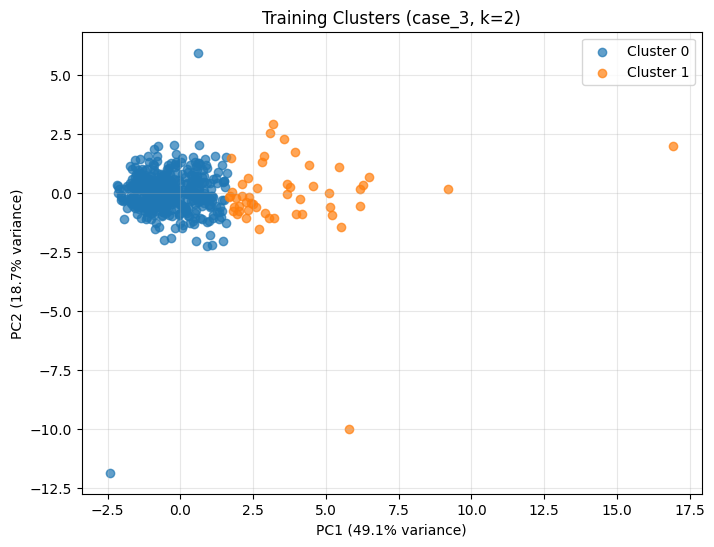

In [26]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Explained variance
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))

# Plot each cluster separately for proper labels
for cluster in np.unique(train_labels):
    mask = train_labels == cluster
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title(f"Training Clusters ({best_case}, k={best_k})")

# Better axis labels with variance explained
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [27]:
pd.Series(train_labels).value_counts()

0    448
1     51
Name: count, dtype: int64

## 22. Final Cluster Assignment Table

In [ ]:
final_clusters = (
    train_clusters
    .merge(val_clusters, on="Symbol", how="left")
)

final_clusters.head()



# Appendix

In [ ]:
# Appendix experiment: single-horizon volume-change feature (vol_chg) for comparison

# Use same full feature table and train/validation windows
train_app = full_feat[(full_feat['Date'] >= data_start) & (full_feat['Date'] <= train_end)].copy()
val_app   = full_feat[(full_feat['Date'] >= val_start) & (full_feat['Date'] <= val_end)].copy()

common_symbols_app = (
    set(train_app['Symbol'].unique())
    & set(val_app['Symbol'].unique())
)

train_app = train_app[train_app['Symbol'].isin(common_symbols_app)].copy()
val_app   = val_app[val_app['Symbol'].isin(common_symbols_app)].copy()

FEATURE_CASES_APP = {
    "case_1_app": ['logret_1', 'logvol_1', 'vol_chg'],
    "case_2_app": ['logret_5', 'logvol_5', 'vol_chg'],
    "case_3_app": ['logret_21', 'logvol_21', 'vol_chg']
}

# 1) Compare feature cases on training
feature_case_results_app = []
for case_name_app, feature_cols_app in FEATURE_CASES_APP.items():
    X_train_case_app = aggregate_features(train_app, feature_cols_app)
    k_results_case_app, _ = evaluate_k_range(X_train_case_app, k_range=range(2, 9))

    best_idx_app = k_results_case_app['silhouette'].idxmax()
    best_k_case_app = int(k_results_case_app.loc[best_idx_app, 'k'])
    best_sil_case_app = float(k_results_case_app.loc[best_idx_app, 'silhouette'])

    feature_case_results_app.append({
        "case": case_name_app,
        "features": ", ".join(feature_cols_app),
        "n_stocks": len(X_train_case_app),
        "aggregated_feature_count": X_train_case_app.shape[1],
        "best_k": best_k_case_app,
        "best_train_silhouette": best_sil_case_app
    })

feature_case_results_app_df = (
    pd.DataFrame(feature_case_results_app)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

# 2) Select best case
best_case_app = feature_case_results_app_df.loc[0, 'case']
best_features_app = FEATURE_CASES_APP[best_case_app]

# 3) Build train matrix and choose k
X_train_app = aggregate_features(train_app, best_features_app)
k_results_app, _ = evaluate_k_range(X_train_app, k_range=range(2, 9))
best_k_app = int(k_results_app.loc[k_results_app['silhouette'].idxmax(), 'k'])

# 4) Fit final train clustering
model_app, scaler_app, train_labels_app, train_score_app, X_train_scaled_app = fit_kmeans(X_train_app, k=best_k_app)

train_clusters_app = pd.DataFrame({
    "Symbol": X_train_app.index,
    "Cluster_train_app": train_labels_app
})

# 5) Validation
X_val_app = aggregate_features(val_app, best_features_app)
common_train_val_app = X_train_app.index.intersection(X_val_app.index)
X_val_app = X_val_app.loc[common_train_val_app]

val_labels_app, val_score_app, X_val_scaled_app = apply_kmeans(X_val_app, model_app, scaler_app)
val_clusters_app = pd.DataFrame({
    "Symbol": X_val_app.index,
    "Cluster_val_app": val_labels_app
})

# 6) Stability summary
stability_summary_app = pd.DataFrame({
    "split": ["train_app", "validation_app"],
    "silhouette": [train_score_app, val_score_app]
})

# 7) Same-stock consistency
train_val_compare_app = train_clusters_app.merge(val_clusters_app, on="Symbol", how="inner")
train_val_consistency_app = (train_val_compare_app["Cluster_train_app"] == train_val_compare_app["Cluster_val_app"]).mean()

# 8) Compare main pipeline vs appendix run
comparison_app = None
if all(v in globals() for v in ['best_case', 'best_k', 'train_score', 'val_score', 'train_val_consistency']):
    comparison_app = pd.DataFrame({
        "metric": [
            "best_case",
            "best_k",
            "train_silhouette",
            "validation_silhouette",
            "train_val_consistency"
        ],
        "main_horizon_matched_volchg": [
            str(best_case),
            int(best_k),
            float(train_score),
            float(val_score),
            float(train_val_consistency)
        ],
        "appendix_single_volchg": [
            str(best_case_app),
            int(best_k_app),
            float(train_score_app),
            float(val_score_app),
            float(train_val_consistency_app)
        ]
    })

print('Appendix best case (single vol_chg):', best_case_app)
print('Appendix selected features:', best_features_app)
print('Appendix selected k:', best_k_app)
print('Appendix consistency (train-val):', round(train_val_consistency_app, 4))

print()
print('Appendix feature case ranking:')
display(feature_case_results_app_df)

print()
print('Appendix stability summary:')
display(stability_summary_app)

if comparison_app is not None:
    print()
    print('Main (horizon-matched) vs Appendix (single vol_chg):')
    display(comparison_app)



## 23. Cluster Profile Interpretation


In [30]:
# Compare cluster means in raw units and z-scores (train split)
train_profile_detail = X_train.copy()
train_profile_detail["Cluster"] = train_labels

cluster_profile_mean = train_profile_detail.groupby("Cluster")[best_features].mean()
overall_mean = X_train[best_features].mean()
overall_std = X_train[best_features].std(ddof=0).replace(0, np.nan)
cluster_profile_z = (cluster_profile_mean - overall_mean) / overall_std

print("Cluster profile: means")
display(cluster_profile_mean.round(4))

print("Cluster profile: z-score vs full train universe")
display(cluster_profile_z.round(3))

if cluster_profile_mean.shape[0] == 2:
    abs_diff = (cluster_profile_mean.iloc[1] - cluster_profile_mean.iloc[0]).abs().sort_values(ascending=False)
    print("Most separating features (absolute mean diff between Cluster 0 and 1)")
    display(abs_diff.to_frame("abs_diff").round(4))


Cluster profile: means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0069,0.0169,0.0033
1,-0.0011,0.0319,0.0068


Cluster profile: z-score vs full train universe


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.062,-0.242,-0.020
1,-0.548,2.128,0.172


Most separating features (absolute mean diff between Cluster 0 and 1)


,abs_diff
logvol_21,0.0149
logret_21,0.0081
vol_chg_21,0.0035


## 24. Sector Composition by Cluster (Train)


Sector counts by cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
Cluster_train,,,,,,,,,,,
0,17,38,36,20,70,53,73,56,23,31,31
1,6,10,0,2,6,6,5,13,3,0,0


Sector percentages within each cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
Cluster_train,,,,,,,,,,,
0,3.79,8.48,8.04,4.46,15.62,11.83,16.29,12.50,5.13,6.92,6.92
1,11.76,19.61,0.00,3.92,11.76,11.76,9.80,25.49,5.88,0.00,0.00


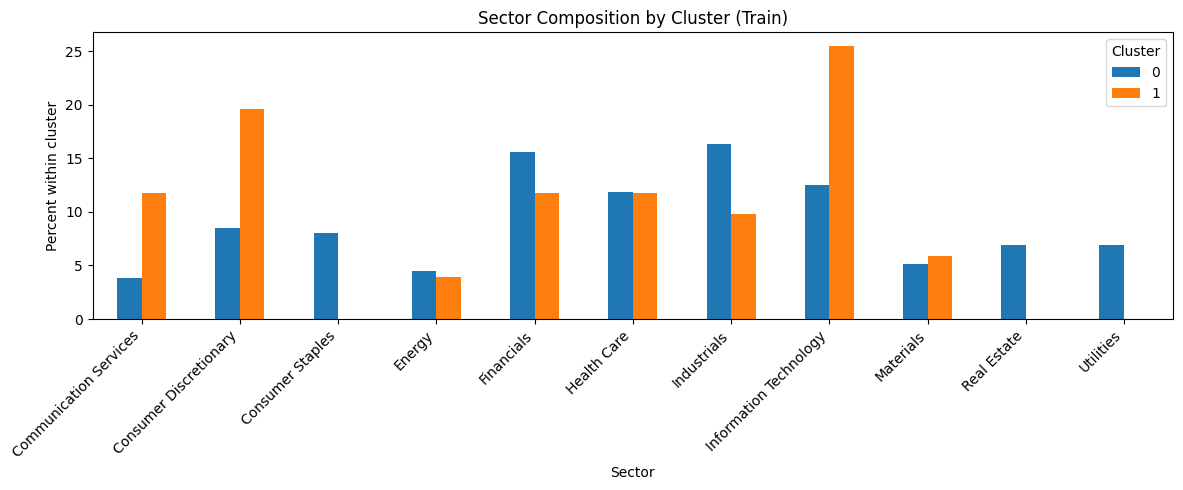

In [31]:
# Sector concentration test: are clusters economically interpretable?
if "Sector" in train.columns:
    sector_col = "Sector"
elif "GICS Sector" in train.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    symbol_sector = (
        train[["Symbol", sector_col]]
        .dropna()
        .drop_duplicates(subset=["Symbol"])
        .rename(columns={sector_col: "Sector"})
    )

    cluster_sector = train_clusters.merge(symbol_sector, on="Symbol", how="left").dropna(subset=["Sector"])

    sector_counts = pd.crosstab(cluster_sector["Cluster_train"], cluster_sector["Sector"])
    sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100

    print("Sector counts by cluster")
    display(sector_counts)

    print("Sector percentages within each cluster")
    display(sector_pct.round(2))

    ax = sector_pct.T.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Sector Composition by Cluster (Train)")
    ax.set_ylabel("Percent within cluster")
    ax.set_xlabel("Sector")
    ax.legend(title="Cluster")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 25. Out-of-Sample Stability Diagnostics


In [ ]:
# Cluster size stability across train/validation
cluster_dist = pd.concat([
    train_clusters["Cluster_train"].value_counts(normalize=True).sort_index().rename("train"),
    val_clusters["Cluster_val"].value_counts(normalize=True).sort_index().rename("validation")
], axis=1).fillna(0)

print("Cluster share by split (%)")
display((cluster_dist * 100).round(2))

ax = (cluster_dist * 100).plot(kind="bar", figsize=(8, 4))
ax.set_title("Cluster Share Stability Across Splits")
ax.set_xlabel("Cluster")
ax.set_ylabel("Percent of stocks")
plt.tight_layout()
plt.show()

# Feature drift check: cluster means by split
train_means = X_train.assign(Cluster=train_labels).groupby("Cluster")[best_features].mean()
val_means = X_val.assign(Cluster=val_labels).groupby("Cluster")[best_features].mean()

print("Train cluster feature means")
display(train_means.round(4))

print("Validation cluster feature means")
display(val_means.round(4))

common_val = train_means.index.intersection(val_means.index)

if len(common_val) > 0:
    print("Validation minus train cluster means")
    display((val_means.loc[common_val] - train_means.loc[common_val]).round(4))



## 26. Name the Clusters + Stock Examples


In [33]:
# Give human-readable names using volatility level
vol_cols = [c for c in best_features if c.startswith("logvol_")]
name_map = {}

if len(vol_cols) > 0 and cluster_profile_mean.shape[0] >= 2:
    vol_col = vol_cols[0]
    ordered = cluster_profile_mean[vol_col].sort_values()
    low_cluster = ordered.index[0]
    high_cluster = ordered.index[-1]

    name_map[low_cluster] = "Lower-vol / steadier"
    name_map[high_cluster] = "Higher-vol / more active"

for c in sorted(set(train_clusters["Cluster_train"])):
    name_map.setdefault(c, f"Cluster {c}")

train_clusters_named = train_clusters.copy()
train_clusters_named["Cluster_name"] = train_clusters_named["Cluster_train"].map(name_map)

print("Cluster naming map")
print(name_map)

cluster_sizes = train_clusters_named["Cluster_name"].value_counts().rename_axis("Cluster_name").reset_index(name="n_stocks")
print("Cluster sizes")
display(cluster_sizes)

stock_examples = (
    train_clusters_named.sort_values(["Cluster_name", "Symbol"])
    .groupby("Cluster_name")["Symbol"]
    .apply(lambda s: ", ".join(s.head(25)))
    .to_frame("example_symbols_first_25")
)

print("Stock examples by cluster")
display(stock_examples)


Cluster naming map
{np.int32(0): 'Lower-vol / steadier', np.int32(1): 'Higher-vol / more active'}
Cluster sizes


,Cluster_name,n_stocks
0,Lower-vol / steadier,448
1,Higher-vol / more active,51


Stock examples by cluster


,example_symbols_first_25
Cluster_name,
Higher-vol / more active,"ABNB, ALB, ALGN, AMD, APA, APP, AXON, BIIB, CC..."
Lower-vol / steadier,"A, AAPL, ABBV, ABT, ACGL, ACN, ADBE, ADI, ADM,..."
